# Perceptron

In [1]:
import numpy as np 

class Perceptron(object):
   
    def __init__(self, input_size, lr=0.2, epochs=4):
        self.W = np.array([0.3,-0.2])
        self.epochs = epochs
        self.lr = lr
    
    def activation_fn(self, x):
        return 1 if x >= 0 else 0
 
    def predict(self, x,theta):
        z = self.W.T.dot(x)-theta
        z=round(z,2)
        a = self.activation_fn(z)
        return a
    
    def fit(self, X, d,theta ,count):
        for _ in range(self.epochs):
            
            print("Epoch: ", count)
            count = count+1
            for i in range(d.shape[0]):
                x = X[i]
                print("input", x , "\t", "Weight:",self.W )
                y = self.predict(x,theta)
                e = d[i] - y
                self.W = self.W + self.lr * e * x
                
if __name__ == '__main__':
    X = np.array([
        [0, 0],
        [0, 1],
        [1, 0],
        [1, 1]
    ])
    d = np.array([0, 0, 0, 1])
 
    perceptron = Perceptron(input_size=2)
    theta=0.4
    count =1
    perceptron.fit(X, d,theta, count)
    print(perceptron.W)


Epoch:  1
input [0 0] 	 Weight: [ 0.3 -0.2]
input [0 1] 	 Weight: [ 0.3 -0.2]
input [1 0] 	 Weight: [ 0.3 -0.2]
input [1 1] 	 Weight: [ 0.3 -0.2]
Epoch:  2
input [0 0] 	 Weight: [0.5 0. ]
input [0 1] 	 Weight: [0.5 0. ]
input [1 0] 	 Weight: [0.5 0. ]
input [1 1] 	 Weight: [0.3 0. ]
Epoch:  3
input [0 0] 	 Weight: [0.5 0.2]
input [0 1] 	 Weight: [0.5 0.2]
input [1 0] 	 Weight: [0.5 0.2]
input [1 1] 	 Weight: [0.3 0.2]
Epoch:  4
input [0 0] 	 Weight: [0.3 0.2]
input [0 1] 	 Weight: [0.3 0.2]
input [1 0] 	 Weight: [0.3 0.2]
input [1 1] 	 Weight: [0.3 0.2]
[0.3 0.2]


# Multi Layer Perceptron

In [2]:
import numpy as np 

def abs(x):
	return x if x>0 else -x

def sigmoid (x):
    return 1/(1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

def checkError(predicted_output):
	expected_output = [[0],[1],[1],[0]]
	for i,j in  zip(expected_output , predicted_output):
		if abs(i[0]-j[0]) > 0.001:
			return True
	return False
inputs = np.array([[0,0],[0,1],[1,0],[1,1]])
expected_output = np.array([[0],[1],[1],[0]])

epoch = 0
lr = 0.1

inputLayerNeurons = int(input("enter no of inputLayer"))
hiddenLayerNeurons = int(input("enter no of hiddenlayer "))
outputLayerNeurons = int(input("enter no of outputlayer "))

hidden_weights = []
for i in range(1,inputLayerNeurons+1):
	hidden_weights_ind = []
	for j in range(inputLayerNeurons+1,inputLayerNeurons+hiddenLayerNeurons+1):
		hidden_weights_ind.append(float(input('w'+str(i)+str(j))))
	hidden_weights.append(hidden_weights_ind)
            
output_weights = []
for i in range(inputLayerNeurons+1,inputLayerNeurons+hiddenLayerNeurons+1):
	output_weights_ind = []
	for j in range(inputLayerNeurons+hiddenLayerNeurons+1,inputLayerNeurons+hiddenLayerNeurons+outputLayerNeurons+1):
		output_weights_ind.append(float(input('w'+str(i)+str(j))))
	output_weights.append(output_weights_ind)

hidden_bias = []
output_bias = []
for i in range(inputLayerNeurons+1,inputLayerNeurons+hiddenLayerNeurons+outputLayerNeurons+1):
	if i > inputLayerNeurons+hiddenLayerNeurons:
		output_bias.append(float(input("o"+str(i))))
	else:
		hidden_bias.append(float(input("o"+str(i))))

hidden_weights = np.asarray(hidden_weights)
hidden_bias = np.asarray([hidden_bias])
output_weights = np.asarray(output_weights)
output_bias = np.asarray([output_bias])

print("Initial hidden weights: ",end='')
print(*hidden_weights)
print("Initial hidden biases: ",end='')
print(*hidden_bias)
print("Initial output weights: ",end='')
print(*output_weights)
print("Initial output biases: ",end='')
print(*output_bias)

predicted_output = [[0],[0],[0],[0]]
while checkError(predicted_output):
	epoch += 1
	
	hidden_layer_activation = np.dot(inputs,hidden_weights)
	hidden_layer_activation += hidden_bias
	hidden_layer_output = sigmoid(hidden_layer_activation)

	output_layer_activation = np.dot(hidden_layer_output,output_weights)
	output_layer_activation += output_bias
	predicted_output = sigmoid(output_layer_activation)

	error = expected_output - predicted_output
	d_predicted_output = error * sigmoid_derivative(predicted_output)
	
	error_hidden_layer = d_predicted_output.dot(output_weights.T)
	d_hidden_layer = error_hidden_layer * sigmoid_derivative(hidden_layer_output)

	output_weights += hidden_layer_output.T.dot(d_predicted_output) * lr
	output_bias += np.sum(d_predicted_output,axis=0,keepdims=True) * lr
	hidden_weights += inputs.T.dot(d_hidden_layer) * lr
	hidden_bias += np.sum(d_hidden_layer,axis=0,keepdims=True) * lr

print("Final hidden weights: ",end='')
print(*hidden_weights)
print("Final hidden bias: ",end='')
print(*hidden_bias)
print("Final output weights: ",end='')
print(*output_weights)
print("Final output bias: ",end='')
print(*output_bias)

print("\nOutput from neural network: ",end='')
print(*predicted_output)
print("\nNo of epochs")
print(epoch)


enter no of inputLayer 2
enter no of hiddenlayer  2
enter no of outputlayer  1
w13 3
w14 6
w23 4
w24 5
w35 2
w45 4
o3 1
o4 6
o5 3.93


Initial hidden weights: [3. 6.] [4. 5.]
Initial hidden biases: [1. 6.]
Initial output weights: [2.] [4.]
Initial output biases: [3.93]
Final hidden weights: [12.20038279  5.94947588] [12.17377329  5.9493075 ]
Final hidden bias: [-4.68736284 -9.08142249]
Final output weights: [14.78898018] [-15.69388708]
Final output bias: [-7.03994693]

Output from neural network: [0.001] [0.99916289] [0.99916298] [0.00085819]

No of epochs
15513879


## Using iris dataset


X_train shape: (40, 4)
X_test shape: (10, 4)
y_train shape: (40,)
y_test shape: (10,)


C:\Users\student\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test Accuracy: 0.8


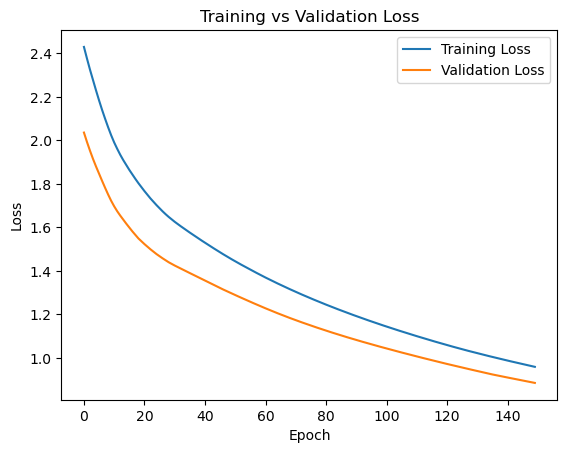

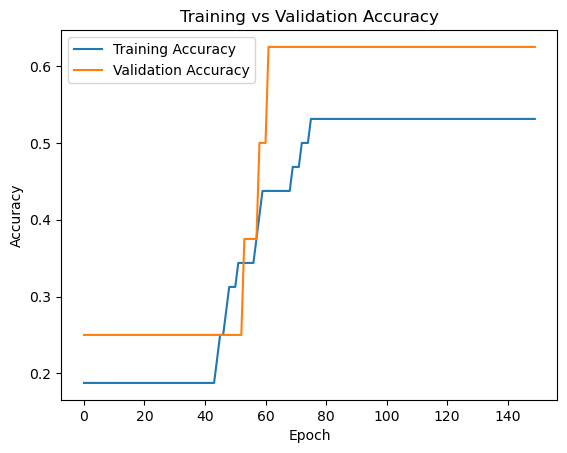

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

df = pd.read_csv("Iris.csv")

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

X = X.astype("float32")
 
y = LabelEncoder().fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

model = Sequential()

model.add(Dense(10, activation="relu", input_shape=(4,)))
model.add(Dense(8, activation="relu"))
model.add(Dense(3, activation="softmax"))

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train,
    y_train,
    epochs=150,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

print("Test Accuracy:", round(accuracy, 3))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [9]:
import numpy as np
def sigmoid(x):
    return 1 / (1 + np.exp(-x))
def sigmoid_derivative(x):
    return x * (1 - x)

X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])
Y = np.array([
    [0],
    [1],
    [1],
    [0]
])

lr = 0.1
W1 = np.array([
    [3, 6],
    [4, 5]
], dtype=float)

B1 = np.array([[1, -6]], dtype=float)

W2 = np.array([
    [2],
    [4]
], dtype=float)

B2 = np.array([[-3.93]], dtype=float)
for epoch in range(100000):

    hidden = sigmoid(np.dot(X, W1) + B1)
    output = sigmoid(np.dot(hidden, W2) + B2)

    error = Y - output
    output_delta = error * sigmoid_derivative(output)

    hidden_error = output_delta.dot(W2.T)
    hidden_delta = hidden_error * sigmoid_derivative(hidden)

    W2 += hidden.T.dot(output_delta) * lr
    B2 += np.sum(output_delta, axis=0, keepdims=True) * lr

    W1 += X.T.dot(hidden_delta) * lr
    B1 += np.sum(hidden_delta, axis=0, keepdims=True) * lr


print("Output from neural network:")
print(np.round(output, 3))

print("\nNumber of epochs:")
print(epoch + 1)

Output from neural network:
[[0.031]
 [0.963]
 [0.963]
 [0.044]]

Number of epochs:
100000
